In [283]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from datetime import datetime
import plotly.express as px
from datetime import datetime
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

mpl.rc('font',family='Malgun Gothic')

##### 업비트 거래기간 2023.01.01 ~ 2025.01.01 로 지정

In [285]:
pd.options.display.float_format = '{:.1f}'.format

In [286]:
import requests
import datetime
import time
import pandas as pd

def fetch_upbit_daily_ohlcv(market="KRW-BTC", start_date="2023-01-01", end_date="2025-01-01"):
    url = "https://api.upbit.com/v1/candles/days"
    headers = {"accept": "application/json"}
    
    end = datetime.datetime.strptime(end_date, "%Y-%m-%d")
    start = datetime.datetime.strptime(start_date, "%Y-%m-%d")

    all_data = []
    to = end 

    while to > start:
        params = {
            'market': market,
            'count': 200,
            'to': to.strftime("%Y-%m-%dT00:00:00Z") 
        }

        response = requests.get(url, params=params, headers=headers)
        if response.status_code != 200:
            print("요청 실패:", response.status_code, response.text)
            break

        data = response.json()
        if not data:
            break
        
        all_data.extend(data)

        oldest = datetime.datetime.strptime(data[-1]['candle_date_time_utc'], "%Y-%m-%dT%H:%M:%S")
        to = oldest - datetime.timedelta(days=1)

        time.sleep(0.1)  

    df = pd.DataFrame(all_data)
    df['candle_date_time_utc'] = pd.to_datetime(df['candle_date_time_utc'])
    df = df[df['candle_date_time_utc'] >= pd.to_datetime(start_date)] 
    df = df.sort_values(by='candle_date_time_utc')

    return df.reset_index(drop=True)

df_coin = fetch_upbit_daily_ohlcv()
print(df_coin[['candle_date_time_utc', 'opening_price', 'high_price', 'low_price', 'trade_price']])


    candle_date_time_utc  opening_price  high_price   low_price  trade_price
0             2023-01-01     21079000.0  21171000.0  21002000.0   21123000.0
1             2023-01-02     21128000.0  21400000.0  21047000.0   21215000.0
2             2023-01-03     21209000.0  21451000.0  21178000.0   21351000.0
3             2023-01-04     21351000.0  21732000.0  21341000.0   21588000.0
4             2023-01-05     21589000.0  21641000.0  21404000.0   21575000.0
..                   ...            ...         ...         ...          ...
723           2024-12-27    144016000.0 146117000.0 141466000.0  142111000.0
724           2024-12-28    142107000.0 143000000.0 141487000.0  142302000.0
725           2024-12-29    142306000.0 142380000.0 138600000.0  139735000.0
726           2024-12-30    139831000.0 140680000.0 135971000.0  137892000.0
727           2024-12-31    137865000.0 143483000.0 136032000.0  139257000.0

[728 rows x 5 columns]


In [287]:
df_coin

,market,candle_date_time_utc,candle_date_time_kst,opening_price,high_price,low_price,trade_price,timestamp,candle_acc_trade_price,candle_acc_trade_volume,prev_closing_price,change_price,change_rate
0,KRW-BTC,2023-01-01,2023-01-01T09:00:00,21079000.0,21171000.0,21002000.0,21123000.0,1672617597561,31357935910.2,1486.5,21079000.0,44000.0,0.0
1,KRW-BTC,2023-01-02,2023-01-02T09:00:00,21128000.0,21400000.0,21047000.0,21215000.0,1672703999647,54848830815.8,2578.8,21123000.0,92000.0,0.0
2,KRW-BTC,2023-01-03,2023-01-03T09:00:00,21209000.0,21451000.0,21178000.0,21351000.0,1672790398972,44770082696.7,2097.6,21215000.0,136000.0,0.0
3,KRW-BTC,2023-01-04,2023-01-04T09:00:00,21351000.0,21732000.0,21341000.0,21588000.0,1672876797009,53380293695.7,2479.2,21351000.0,237000.0,0.0
4,KRW-BTC,2023-01-05,2023-01-05T09:00:00,21589000.0,21641000.0,21404000.0,21575000.0,1672963199288,76705645075.1,3563.0,21588000.0,-13000.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,KRW-BTC,2024-12-27,2024-12-27T09:00:00,144016000.0,146117000.0,141466000.0,142111000.0,1735343999444,464668960489.3,3231.3,144076000.0,-1965000.0,-0.0
724,KRW-BTC,2024-12-28,2024-12-28T09:00:00,142107000.0,143000000.0,141487000.0,142302000.0,1735430399613,186348569009.1,1311.6,142111000.0,191000.0,0.0
725,KRW-BTC,2024-12-29,2024-12-29T09:00:00,142306000.0,142380000.0,138600000.0,139735000.0,1735516799943,306515266961.4,2180.4,142302000.0,-2567000.0,-0.0
726,KRW-BTC,2024-12-30,2024-12-30T09:00:00,139831000.0,140680000.0,135971000.0,137892000.0,1735603199382,520848698110.8,3767.7,139735000.0,-1843000.0,-0.0


In [288]:
df_coin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 728 entries, 0 to 727
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   market                   728 non-null    object        
 1   candle_date_time_utc     728 non-null    datetime64[ns]
 2   candle_date_time_kst     728 non-null    object        
 3   opening_price            728 non-null    float64       
 4   high_price               728 non-null    float64       
 5   low_price                728 non-null    float64       
 6   trade_price              728 non-null    float64       
 7   timestamp                728 non-null    int64         
 8   candle_acc_trade_price   728 non-null    float64       
 9   candle_acc_trade_volume  728 non-null    float64       
 10  prev_closing_price       728 non-null    float64       
 11  change_price             728 non-null    float64       
 12  change_rate              728 non-nul

##### 2023.01.01 ~ 2025.01.01 의 평균기온, 최저기온, 최고기온을 나타낸 DataFrame

In [289]:
df_temp = pd.read_csv('weather.csv', encoding='cp949', skiprows=6)
df_temp

,날짜,지점,평균기온(℃),최저기온(℃),최고기온(℃)
0,\t2024-01-01,108,3.3,-0.3,7.3
1,\t2024-01-02,108,2.9,2.2,4.3
2,\t2024-01-03,108,1.8,-1.1,4.0
3,\t2024-01-04,108,1.4,-3.3,4.7
4,\t2024-01-05,108,5.0,1.4,9.1
...,...,...,...,...,...
362,\t2024-12-28,108,-3.0,-6.7,1.1
363,\t2024-12-29,108,1.1,-4.2,6.1
364,\t2024-12-30,108,5.5,1.9,10.1
365,\t2024-12-31,108,0.6,-2.0,4.9


In [290]:
df_temp['날짜'] = df_temp['날짜'].astype(str).str.strip('\t')
df_temp.drop('지점', axis=1, inplace=True)
df_temp

,날짜,평균기온(℃),최저기온(℃),최고기온(℃)
0,2024-01-01,3.3,-0.3,7.3
1,2024-01-02,2.9,2.2,4.3
2,2024-01-03,1.8,-1.1,4.0
3,2024-01-04,1.4,-3.3,4.7
4,2024-01-05,5.0,1.4,9.1
...,...,...,...,...
362,2024-12-28,-3.0,-6.7,1.1
363,2024-12-29,1.1,-4.2,6.1
364,2024-12-30,5.5,1.9,10.1
365,2024-12-31,0.6,-2.0,4.9


In [291]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   날짜       367 non-null    object 
 1   평균기온(℃)  367 non-null    float64
 2   최저기온(℃)  367 non-null    float64
 3   최고기온(℃)  367 non-null    float64
dtypes: float64(3), object(1)
memory usage: 11.6+ KB


In [292]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from datetime import datetime
import plotly.express as px
from datetime import datetime
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

mpl.rc('font',family='Malgun Gothic')

##### 필요한 컬럼들만 추출하여 새로운 DataFrame 생성

In [297]:


# df_temp['날짜'] = pd.to_datetime(df_temp['날짜']) # 날짜 형식 변환

# merged = pd.merge(df_coin, df_temp, on='날짜', how='inner')
# #
# data = merged[['날짜', '평균기온(℃)', 'candle_acc_trade_volume']].dropna()

# data

In [294]:
merged

,market,candle_date_time_utc,candle_date_time_kst,opening_price,high_price,low_price,trade_price,timestamp,candle_acc_trade_price,candle_acc_trade_volume,prev_closing_price,change_price,change_rate,날짜,date,평균기온(℃),최저기온(℃),최고기온(℃)
0,KRW-BTC,2024-01-01,2024-01-01T09:00:00,57045000.0,58847000.0,57045000.0,58839000.0,1704153599562,182491217914.3,3165.3,57047000.0,1792000.0,0.0,2024-01-01,2024-01-01,3.3,-0.3,7.3
1,KRW-BTC,2024-01-02,2024-01-02T09:00:00,58839000.0,60997000.0,58814000.0,60206000.0,1704239999808,495038780463.8,8221.2,58839000.0,1367000.0,0.0,2024-01-02,2024-01-02,2.9,2.2,4.3
2,KRW-BTC,2024-01-03,2024-01-03T09:00:00,60205000.0,60799000.0,54346000.0,58581000.0,1704326399884,945841183535.2,16310.3,60206000.0,-1625000.0,-0.0,2024-01-03,2024-01-03,1.8,-1.1,4.0
3,KRW-BTC,2024-01-04,2024-01-04T09:00:00,58581000.0,60162000.0,57319000.0,59477000.0,1704412798132,366025648066.8,6254.5,58581000.0,896000.0,0.0,2024-01-04,2024-01-04,1.4,-3.3,4.7
4,KRW-BTC,2024-01-05,2024-01-05T09:00:00,59477000.0,59695000.0,57577000.0,59351000.0,1704499198889,284352418527.1,4822.4,59477000.0,-126000.0,-0.0,2024-01-05,2024-01-05,5.0,1.4,9.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,KRW-BTC,2024-12-27,2024-12-27T09:00:00,144016000.0,146117000.0,141466000.0,142111000.0,1735343999444,464668960489.3,3231.3,144076000.0,-1965000.0,-0.0,2024-12-27,2024-12-27,-2.6,-5.9,1.8
361,KRW-BTC,2024-12-28,2024-12-28T09:00:00,142107000.0,143000000.0,141487000.0,142302000.0,1735430399613,186348569009.1,1311.6,142111000.0,191000.0,0.0,2024-12-28,2024-12-28,-3.0,-6.7,1.1
362,KRW-BTC,2024-12-29,2024-12-29T09:00:00,142306000.0,142380000.0,138600000.0,139735000.0,1735516799943,306515266961.4,2180.4,142302000.0,-2567000.0,-0.0,2024-12-29,2024-12-29,1.1,-4.2,6.1
363,KRW-BTC,2024-12-30,2024-12-30T09:00:00,139831000.0,140680000.0,135971000.0,137892000.0,1735603199382,520848698110.8,3767.7,139735000.0,-1843000.0,-0.0,2024-12-30,2024-12-30,5.5,1.9,10.1


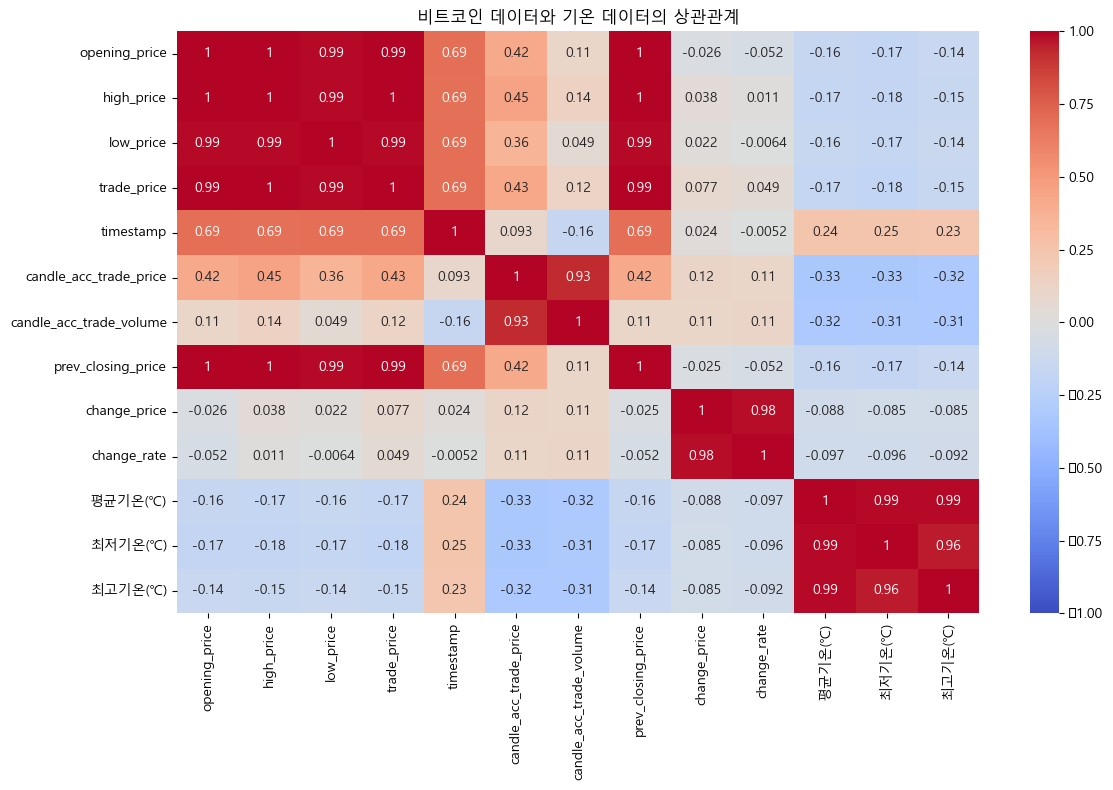

In [295]:
numeric_columns = merged.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = merged[numeric_columns].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, 
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0)
plt.title('비트코인 데이터와 기온 데이터의 상관관계')
plt.tight_layout()
plt.show()


기온과 거래 데이터 간의 높은 상관관계는 존재하지 않음
- 상관관계가 상대적으로 높은 거래가와 평균기온 간의 관계 시각화

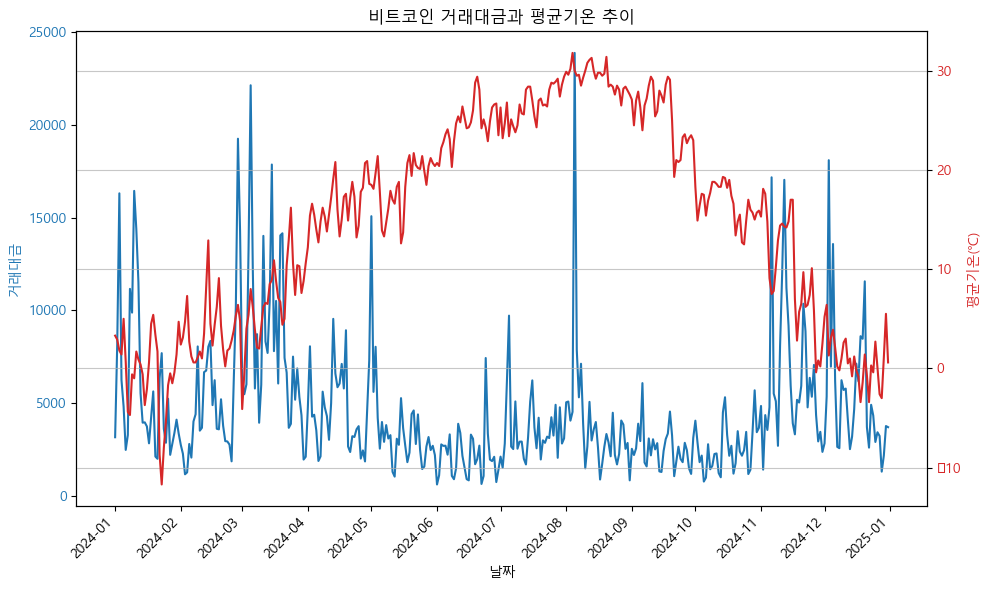

In [282]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('날짜')
ax1.set_ylabel('거래대금', color='tab:blue')
ax1.plot(merged['날짜'], merged['candle_acc_trade_volume'], color='tab:blue', label='거래대금')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2 = ax1.twinx()  
ax2.set_ylabel('평균기온(℃)', color='tab:red')  
ax2.plot(merged['날짜'], merged['평균기온(℃)'], color='tab:red', label='평균기온(℃)')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('비트코인 거래대금과 평균기온 추이')
plt.grid(True, which='major', axis='both', alpha=0.7)
fig.tight_layout()
plt.show()

##### 그래프 해석

- 거래대금은 연중 큰 변동성을 보이며, 특히 1월~3월 사이에 높은 거래량이 있었음
- 평균기온은 계절성을 보이며 여름(7-8월)에 높고 겨울(12-1월)에 낮은 패턴을 보임
- 거래대금과 평균기온 사이의 뚜렷한 상관관계는 보이지 않음
- 거래대금의 급격한 증가는 기온과 무관하게 발생함

** 왜 24년도 3월, 8월, 11월에 거래량이 급등했을까?
- 📈 2024년 3월: 비트코인 현물 ETF 승인과 가격 급등
주요 이슈: 미국 증권거래위원회(SEC)가 2024년 1월에 비트코인 현물 ETF를 승인하면서, 3월에는 이러한 ETF들에 대한 투자자들의 관심이 급증

- 📈 2024년 8월: 비트코인 반감기 이후의 기대감
주요 이슈: 2024년 4월에 발생한 비트코인 반감기 이후, 8월에는 공급 감소에 따른 가격 상승 기대감이 확산

- 📈 2024년 11월: 트럼프 대통령 재선과 규제 완화 기대
주요 이슈: 2024년 11월 6일, 도널드 트럼프 전 대통령이 재선에 성공하면서, 그의 친암호화폐 정책에 대한 기대감이 시장에 확산

In [263]:
# --- 1. 날씨 데이터 수집 ---
def collect_weather_data_for_year(start_date, end_date):
    service_key = "O2tcmFEOD4/5zZZs149rtDhrwts8sfaWpgxS/px1R6S9/l78B+Vpb5HrnTnYLnxX4cyNfVirUpCpD4xNGxfzNg=="
    base_url = "http://apis.data.go.kr/1360000/AsosDalyInfoService/getWthrDataList"
    stn_ids = "108"  # 서울
    num_of_rows = 999

    # ServiceKey 디코딩
    try:
        service_key = unquote(service_key)
    except Exception as e:
        print(f"ServiceKey decoding error: {e}")
        return []

    data_list = []
    page_no = 1

    while True:
        params = {
            "ServiceKey": service_key,
            "dataType": "JSON",
            "dataCd": "ASOS",
            "dateCd": "DAY",
            "stnIds": stn_ids,
            "startDt": start_date,
            "endDt": end_date,
            "numOfRows": str(num_of_rows),
            "pageNo": str(page_no)
        }

        try:
            response = requests.get(base_url, params=params, timeout=10)
            response.raise_for_status()
        except requests.RequestException as e:
            print(f"Weather Request Error for {start_date} to {end_date}: {e}")
            break

        try:
            json_data = response.json()
        except ValueError as e:
            print(f"Weather JSON Decode Error for {start_date} to {end_date}: {e}")
            break

        result_code = json_data.get("response", {}).get("header", {}).get("resultCode", "Unknown")
        if result_code != "00":
            print(f"Weather API Error for {start_date} to {end_date} - Code: {result_code}, Message: {json_data.get('response', {}).get('header', {}).get('resultMsg', 'Unknown')}")
            break

        try:
            items = json_data["response"]["body"]["items"]["item"]
            for item in items:
                data_list.append({
                    "date": item.get("tm", None),
                    "avg_temp": item.get("avgTa", None),
                    "max_temp": item.get("maxTa", None),
                    "min_temp": item.get("minTa", None),
                    "precipitation": item.get("sumRn", None),
                    "avg_wind_speed": item.get("avgWs", None),
                    "avg_humidity": item.get("avgRhm", None)
                })
        except (KeyError, TypeError) as e:
            print(f"Weather Data extraction error for {start_date} to {end_date}: {e}")
            break

        total_count = json_data["response"]["body"]["totalCount"]
        print(f"Weather Page {page_no} for {start_date} to {end_date}, Total Count: {total_count}")
        if page_no * num_of_rows >= total_count:
            break
        page_no += 1
        time.sleep(0.2)

    return data_list

def collect_weather_data():
    years = [
        ("20220101", "20221231"),  # 2022년
        ("20230101", "20231231"),  # 2023년
        ("20240101", "20241231")   # 2024년
    ]
    all_data = []

    for start_date, end_date in years:
        print(f"Collecting weather data for {start_date} to {end_date}")
        year_data = collect_weather_data_for_year(start_date, end_date)
        all_data.extend(year_data)
        time.sleep(1)  # 연도 간 요청 지연 추가

    return all_data

In [264]:
collect_weather_data()

Weather Page 1 for 20220101 to 20221231, Total Count: 365
Weather Page 1 for 20230101 to 20231231, Total Count: 365
Weather Page 1 for 20240101 to 20241231, Total Count: 366


[{'date': '2022-01-01',
  'avg_temp': '-4.3',
  'max_temp': '2.3',
  'min_temp': '-10.2',
  'precipitation': '',
  'avg_wind_speed': '1.5',
  'avg_humidity': '46.3'},
 {'date': '2022-01-02',
  'avg_temp': '-1.3',
  'max_temp': '3.0',
  'min_temp': '-5.2',
  'precipitation': '0.3',
  'avg_wind_speed': '2.3',
  'avg_humidity': '57.9'},
 {'date': '2022-01-03',
  'avg_temp': '-1.9',
  'max_temp': '2.5',
  'min_temp': '-8.0',
  'precipitation': '0.0',
  'avg_wind_speed': '1.8',
  'avg_humidity': '58.3'},
 {'date': '2022-01-04',
  'avg_temp': '-2.5',
  'max_temp': '1.0',
  'min_temp': '-5.6',
  'precipitation': '0.0',
  'avg_wind_speed': '2.4',
  'avg_humidity': '51.8'},
 {'date': '2022-01-05',
  'avg_temp': '-2.8',
  'max_temp': '1.9',
  'min_temp': '-7.8',
  'precipitation': '',
  'avg_wind_speed': '1.7',
  'avg_humidity': '47.6'},
 {'date': '2022-01-06',
  'avg_temp': '-2.2',
  'max_temp': '3.3',
  'min_temp': '-5.9',
  'precipitation': '',
  'avg_wind_speed': '2.3',
  'avg_humidity': '47

In [265]:
# 날씨 데이터
weather_data = collect_weather_data()
if not weather_data:
    print("날씨 데이터 수집 실패")
    exit()

df_weather = pd.DataFrame(weather_data)
df_weather["date"] = pd.to_datetime(df_weather["date"])
numeric_columns_weather = ["avg_temp", "max_temp", "min_temp", "precipitation", 
                          "avg_wind_speed", "avg_humidity"]
df_weather[numeric_columns_weather] = df_weather[numeric_columns_weather].apply(pd.to_numeric, errors="coerce")
df_weather = df_weather.sort_values("date")

Weather Page 1 for 20220101 to 20221231, Total Count: 365
Weather Page 1 for 20230101 to 20231231, Total Count: 365
Weather Page 1 for 20240101 to 20241231, Total Count: 366


In [266]:
df_weather

,date,avg_temp,max_temp,min_temp,precipitation,avg_wind_speed,avg_humidity
0,2022-01-01,-4.3,2.3,-10.2,NaN,1.5,46.3
1,2022-01-02,-1.3,3.0,-5.2,0.3,2.3,57.9
2,2022-01-03,-1.9,2.5,-8.0,0.0,1.8,58.3
3,2022-01-04,-2.5,1.0,-5.6,0.0,2.4,51.8
4,2022-01-05,-2.8,1.9,-7.8,NaN,1.7,47.6
...,...,...,...,...,...,...,...
1091,2024-12-27,-2.6,1.8,-5.9,0.0,2.7,51.4
1092,2024-12-28,-3.0,1.1,-6.7,NaN,2.5,48.3
1093,2024-12-29,1.1,6.1,-4.2,NaN,1.5,56.1
1094,2024-12-30,5.5,10.1,1.9,0.0,2.3,68.5


In [298]:
# 날짜 형식 통일
df_coin['date'] = pd.to_datetime(df_coin['candle_date_time_kst']).dt.date
df_weather['date'] = pd.to_datetime(df_weather['date']).dt.date

# 병합 (inner join: 양쪽 다 있는 날짜만 사용)
df_merged = pd.merge(df_coin, df_weather, on='date', how='inner')
df_merged = df_merged.drop(['candle_date_time_utc', 'candle_date_time_kst'], axis=1)

df_merged


,market,opening_price,high_price,low_price,trade_price,timestamp,candle_acc_trade_price,candle_acc_trade_volume,prev_closing_price,change_price,change_rate,date,avg_temp,max_temp,min_temp,precipitation,avg_wind_speed,avg_humidity,month
0,KRW-BTC,21079000.0,21171000.0,21002000.0,21123000.0,1672617597561,31357935910.2,1486.5,21079000.0,44000.0,0.0,2023-01-01,-0.2,3.8,-4.3,NaN,2.7,54.5,1
1,KRW-BTC,21128000.0,21400000.0,21047000.0,21215000.0,1672703999647,54848830815.8,2578.8,21123000.0,92000.0,0.0,2023-01-02,-4.5,-0.4,-7.4,NaN,2.5,45.9,1
2,KRW-BTC,21209000.0,21451000.0,21178000.0,21351000.0,1672790398972,44770082696.7,2097.6,21215000.0,136000.0,0.0,2023-01-03,-5.0,0.6,-9.0,NaN,1.8,49.0,1
3,KRW-BTC,21351000.0,21732000.0,21341000.0,21588000.0,1672876797009,53380293695.7,2479.2,21351000.0,237000.0,0.0,2023-01-04,-1.8,3.3,-5.7,NaN,1.9,51.4,1
4,KRW-BTC,21589000.0,21641000.0,21404000.0,21575000.0,1672963199288,76705645075.1,3563.0,21588000.0,-13000.0,-0.0,2023-01-05,-1.6,3.6,-5.6,NaN,1.6,58.1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,KRW-BTC,144016000.0,146117000.0,141466000.0,142111000.0,1735343999444,464668960489.3,3231.3,144076000.0,-1965000.0,-0.0,2024-12-27,-2.6,1.8,-5.9,0.0,2.7,51.4,12
724,KRW-BTC,142107000.0,143000000.0,141487000.0,142302000.0,1735430399613,186348569009.1,1311.6,142111000.0,191000.0,0.0,2024-12-28,-3.0,1.1,-6.7,NaN,2.5,48.3,12
725,KRW-BTC,142306000.0,142380000.0,138600000.0,139735000.0,1735516799943,306515266961.4,2180.4,142302000.0,-2567000.0,-0.0,2024-12-29,1.1,6.1,-4.2,NaN,1.5,56.1,12
726,KRW-BTC,139831000.0,140680000.0,135971000.0,137892000.0,1735603199382,520848698110.8,3767.7,139735000.0,-1843000.0,-0.0,2024-12-30,5.5,10.1,1.9,0.0,2.3,68.5,12


In [301]:
# 날짜 형식 통일
df_coin['date'] = pd.to_datetime(df_coin['candle_date_time_kst']).dt.date
df_weather['date'] = pd.to_datetime(df_weather['date']).dt.date

# 병합 (inner join: 양쪽 다 있는 날짜만 사용)
df_merged = pd.merge(df_coin, df_weather, on='date', how='inner')
df_merged = df_merged.drop(['candle_date_time_utc', 'candle_date_time_kst'], axis=1)

# 'month' 컬럼 추가
df_merged['month'] = pd.to_datetime(df_merged['date']).dt.month

# 월별로 그룹화하여 평균 계산 (새로운 데이터프레임 생성)
df_monthly_avg = df_merged.groupby('month').mean(numeric_only=True).reset_index()

df_monthly_avg

,month,opening_price,high_price,low_price,trade_price,timestamp,candle_acc_trade_price,candle_acc_trade_volume,prev_closing_price,change_price,change_rate,avg_temp,max_temp,min_temp,precipitation,avg_wind_speed,avg_humidity
0,1,41891951.6,42705451.6,41131596.8,42046338.7,1689681599242.9,236413320090.8,5289.1,41890274.2,156064.5,0.0,-1.0,3.4,-4.8,2.5,2.4,64.9
1,2,49193666.7,50217087.7,48654964.9,49704877.2,1692529010106.1,302644950530.9,6304.4,49193789.5,511087.7,0.0,3.1,7.8,-0.8,4.2,2.4,66.0
2,3,64769887.1,66319129.0,63413838.7,65116693.5,1694822399721.9,521839258676.8,7854.3,64768693.5,348000.0,0.0,8.4,14.1,3.3,2.7,2.5,54.2
3,4,67294116.7,68228700.0,65954233.3,67087316.7,1697457599500.6,310929857492.9,4642.5,67291050.0,-203733.3,-0.0,15.1,20.7,10.1,6.2,2.4,58.1
4,5,64383950.8,65376278.7,63381754.1,64454311.5,1700361914095.4,226943040906.8,3526.8,64377016.4,77295.1,0.0,19.0,24.4,14.3,14.0,2.4,63.0
5,6,64237661.0,65074949.2,63445305.1,64203966.1,1702462209120.5,179563131705.2,3229.0,64234355.9,-30389.8,0.0,23.9,28.9,19.8,11.5,2.2,66.6
6,7,63723983.9,64693129.0,62774403.2,63721241.9,1705363199300.2,212563935489.4,3236.7,63724354.8,-3112.9,-0.0,26.7,29.9,24.0,22.1,2.3,81.0
7,8,60446177.4,61419129.0,59280016.1,60246258.1,1708041598989.9,230517554018.9,3693.8,60448032.3,-201774.2,-0.0,28.3,32.0,25.3,10.3,2.1,74.5
8,9,58240366.7,59034550.0,57522550.0,58314683.3,1710676798931.1,154733238164.9,2727.2,58238583.3,76100.0,0.0,24.6,28.7,21.1,10.3,2.2,72.6
9,10,64609774.2,65736548.4,63998806.5,65012112.9,1713311999229.8,199215026068.1,3286.5,64611919.4,400193.5,0.0,16.2,21.2,12.1,5.2,2.0,68.1


In [302]:
df_corr = df_monthly_avg.corr(numeric_only=True)
df_corr

,month,opening_price,high_price,low_price,trade_price,timestamp,candle_acc_trade_price,candle_acc_trade_volume,prev_closing_price,change_price,change_rate,avg_temp,max_temp,min_temp,precipitation,avg_wind_speed,avg_humidity
month,1.0,0.8,0.8,0.8,0.8,1.0,0.2,-0.4,0.8,0.1,-0.1,0.2,0.2,0.3,0.1,-0.6,0.3
opening_price,0.8,1.0,1.0,1.0,1.0,0.8,0.7,0.1,1.0,0.2,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.2
high_price,0.8,1.0,1.0,1.0,1.0,0.8,0.7,0.1,1.0,0.2,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.2
low_price,0.8,1.0,1.0,1.0,1.0,0.8,0.7,0.1,1.0,0.2,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.2
trade_price,0.8,1.0,1.0,1.0,1.0,0.8,0.7,0.1,1.0,0.2,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.2
timestamp,1.0,0.8,0.8,0.8,0.8,1.0,0.2,-0.4,0.8,0.1,-0.1,0.2,0.2,0.3,0.1,-0.6,0.3
candle_acc_trade_price,0.2,0.7,0.7,0.7,0.7,0.2,1.0,0.8,0.7,0.5,0.4,-0.6,-0.6,-0.6,-0.5,0.5,-0.6
candle_acc_trade_volume,-0.4,0.1,0.1,0.1,0.1,-0.4,0.8,1.0,0.1,0.5,0.6,-0.8,-0.7,-0.8,-0.7,0.7,-0.7
prev_closing_price,0.8,1.0,1.0,1.0,1.0,0.8,0.7,0.1,1.0,0.2,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.2
change_price,0.1,0.2,0.2,0.2,0.2,0.1,0.5,0.5,0.2,1.0,0.9,-0.6,-0.6,-0.6,-0.5,0.1,-0.3


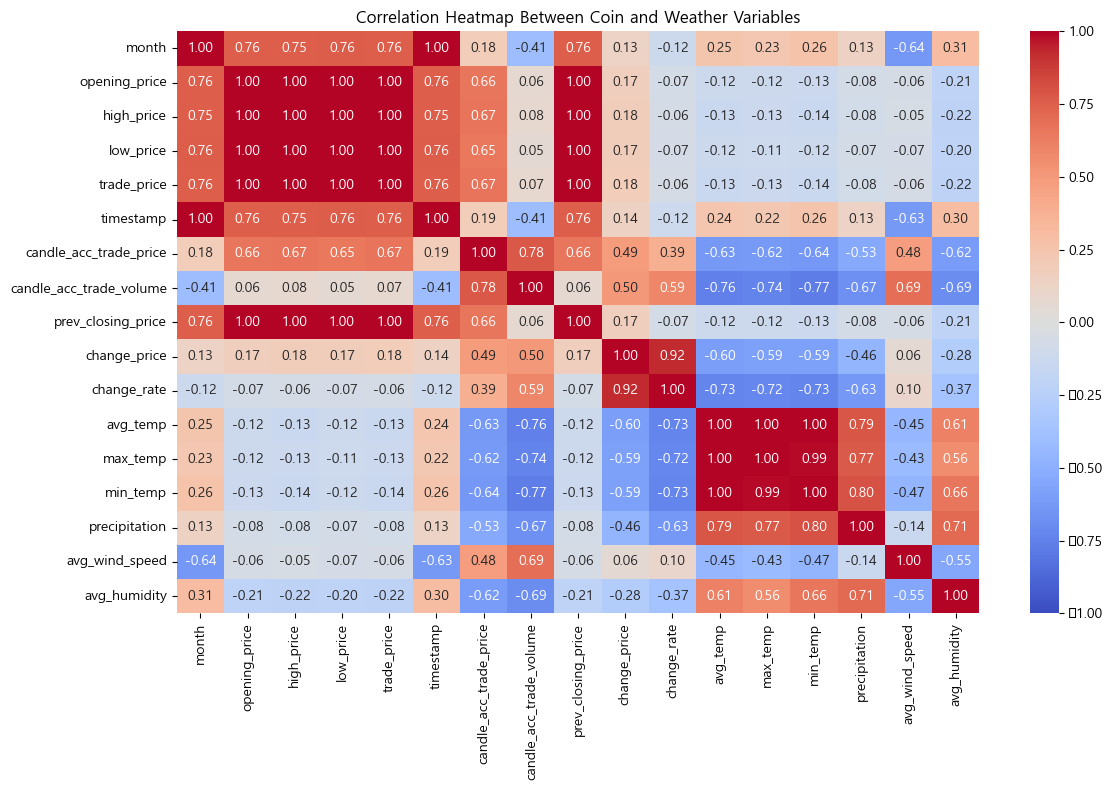

In [303]:

# 숫자형 컬럼만 선택 (문자형, 시간형 제거)
df_corr = df_monthly_avg.select_dtypes(include=['number'])

# 상관계수 행렬 계산
corr_matrix = df_corr.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap Between Coin and Weather Variables")
plt.tight_layout()
plt.show()


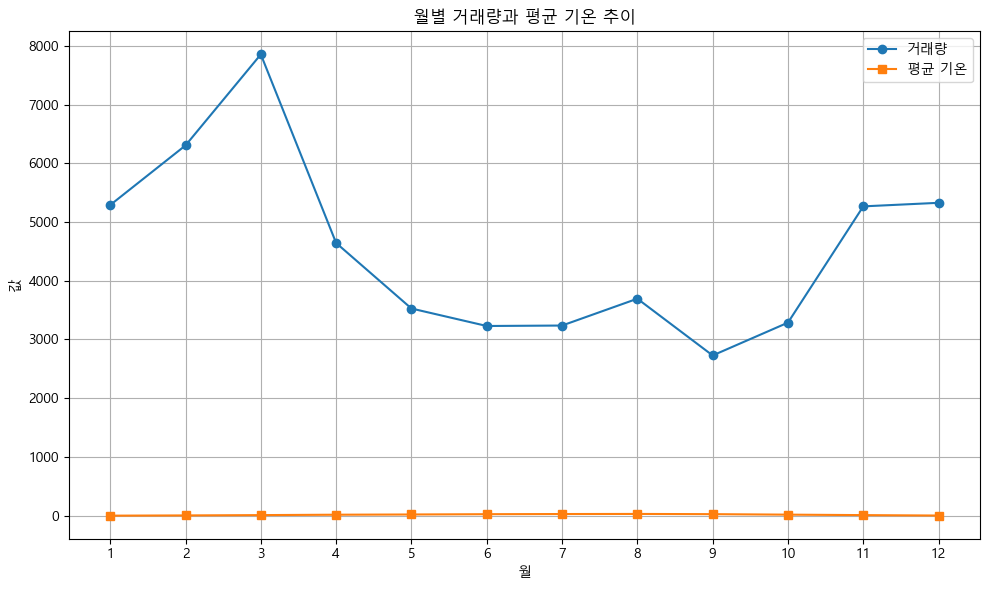

In [304]:
plt.figure(figsize=(10, 6))

# 거래량 추이
plt.plot(df_monthly_avg['month'], df_monthly_avg['candle_acc_trade_volume'], label='거래량', marker='o')

# 평균 기온 추이
plt.plot(df_monthly_avg['month'], df_monthly_avg['avg_temp'], label='평균 기온', marker='s')

plt.title('월별 거래량과 평균 기온 추이')
plt.xlabel('월')
plt.ylabel('값')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [299]:
df_corr = df_merged.corr(numeric_only=True)
df_corr

,opening_price,high_price,low_price,trade_price,timestamp,candle_acc_trade_price,candle_acc_trade_volume,prev_closing_price,change_price,change_rate,avg_temp,max_temp,min_temp,precipitation,avg_wind_speed,avg_humidity,month
opening_price,1.0,1.0,1.0,1.0,0.9,0.6,0.0,1.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.1,-0.0,-0.1,0.3
high_price,1.0,1.0,1.0,1.0,0.9,0.6,0.1,1.0,0.1,-0.0,-0.0,-0.0,-0.0,-0.1,-0.0,-0.1,0.3
low_price,1.0,1.0,1.0,1.0,0.9,0.5,0.0,1.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.1,-0.0,-0.1,0.3
trade_price,1.0,1.0,1.0,1.0,0.9,0.6,0.0,1.0,0.1,0.0,-0.0,-0.0,-0.0,-0.1,-0.0,-0.1,0.3
timestamp,0.9,0.9,0.9,0.9,1.0,0.4,-0.1,0.9,0.0,-0.0,0.1,0.1,0.2,-0.0,-0.1,0.1,0.5
candle_acc_trade_price,0.6,0.6,0.5,0.6,0.4,1.0,0.8,0.6,0.1,0.1,-0.2,-0.2,-0.2,-0.1,0.0,-0.2,0.1
candle_acc_trade_volume,0.0,0.1,0.0,0.0,-0.1,0.8,1.0,0.0,0.1,0.2,-0.3,-0.3,-0.3,-0.1,0.0,-0.2,-0.2
prev_closing_price,1.0,1.0,1.0,1.0,0.9,0.6,0.0,1.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.1,-0.0,-0.1,0.3
change_price,0.0,0.1,0.0,0.1,0.0,0.1,0.1,0.0,1.0,0.9,-0.1,-0.1,-0.1,0.0,-0.1,-0.0,0.0
change_rate,-0.0,-0.0,-0.0,0.0,-0.0,0.1,0.2,-0.0,0.9,1.0,-0.1,-0.1,-0.1,0.0,-0.1,-0.1,-0.0


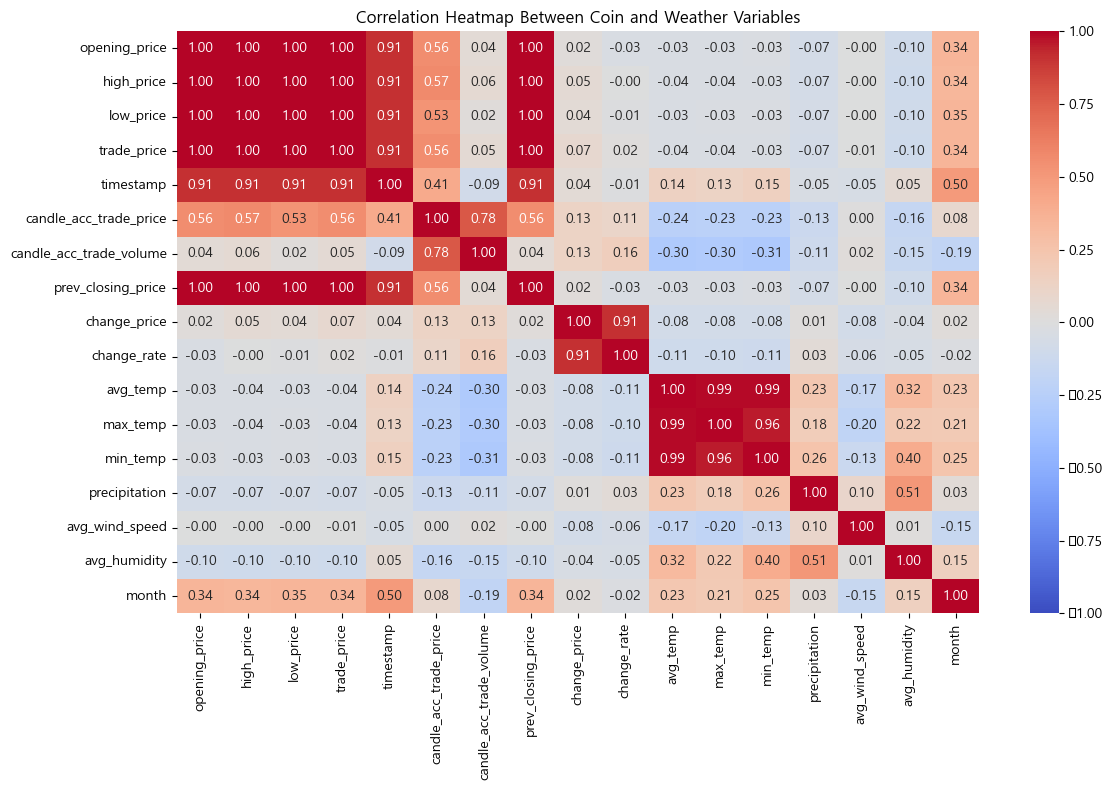

In [300]:

# 숫자형 컬럼만 선택 (문자형, 시간형 제거)
df_corr = df_merged.select_dtypes(include=['number'])

# 상관계수 행렬 계산
corr_matrix = df_corr.corr()

# 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap Between Coin and Weather Variables")
plt.tight_layout()
plt.show()


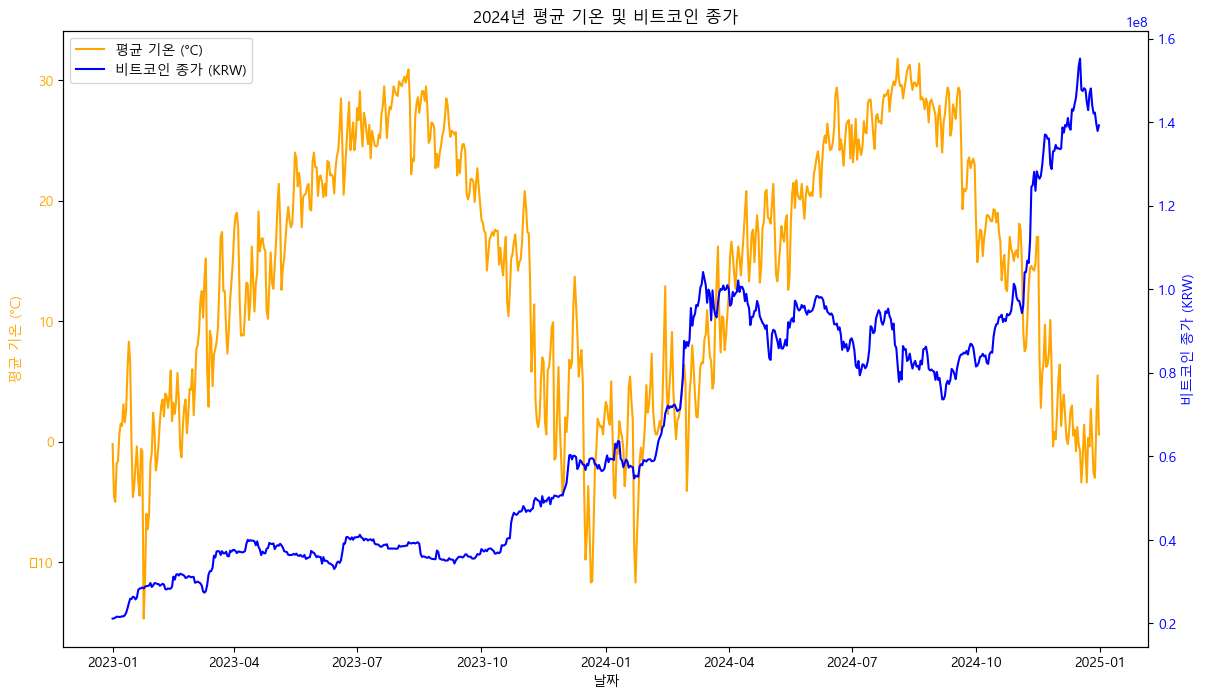

In [270]:
plt.figure(figsize=(14, 8))

# 평균 기온 플롯
ax1 = plt.gca()  # 현재 축 가져오기
ax1.plot(df_merged['date'], df_merged['avg_temp'], label='평균 기온 (°C)', color='orange')
ax1.set_xlabel('날짜')
ax1.set_ylabel('평균 기온 (°C)', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_title('2024년 평균 기온 및 비트코인 종가')

# 비트코인 가격을 위한 두 번째 y축
ax2 = ax1.twinx()
ax2.plot(df_merged['date'], df_merged['trade_price'], label='비트코인 종가 (KRW)', color='blue')
ax2.set_ylabel('비트코인 종가 (KRW)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# 범례 결합
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

<Figure size 800x600 with 0 Axes>

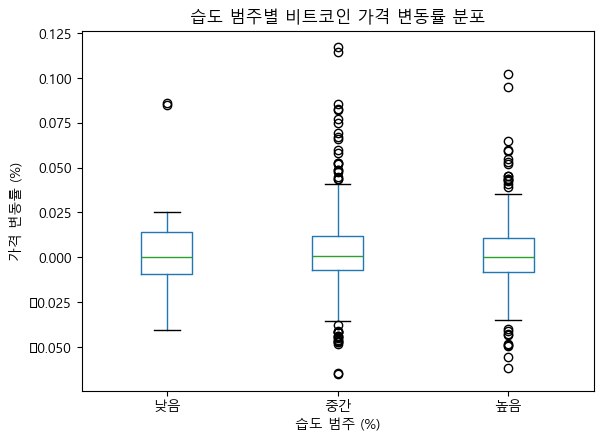

In [271]:


# 습도를 범주화 (낮음: 0-40%, 중간: 40-70%, 높음: 70-100%)
df_merged['humidity_category'] = pd.cut(df_merged['avg_humidity'], 
                                        bins=[0, 40, 70, 100], 
                                        labels=['낮음', '중간', '높음'])

plt.figure(figsize=(8, 6))
df_merged.boxplot(column='change_rate', by='humidity_category', grid=False)
plt.title('습도 범주별 비트코인 가격 변동률 분포')
plt.xlabel('습도 범주 (%)')
plt.ylabel('가격 변동률 (%)')
plt.suptitle('')
plt.show()

<Figure size 1000x600 with 0 Axes>

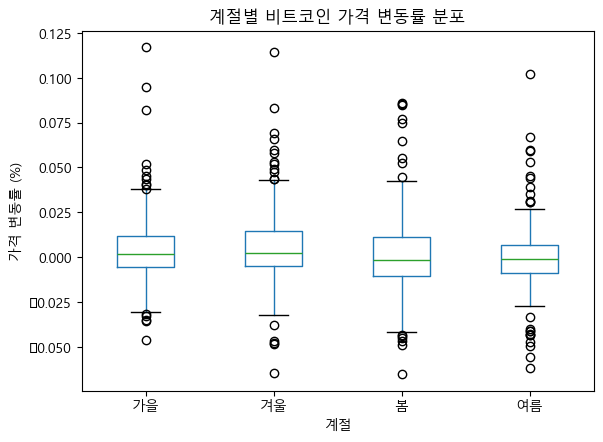

In [272]:
# 날짜에서 월 추출
df_merged['month'] = pd.to_datetime(df_merged['date']).dt.month

# 계절 매핑 함수
def get_season(month):
    if month in [12, 1, 2]:
        return '겨울'
    elif month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    else:  # 9, 10, 11
        return '가을'

# 계절 열 추가
df_merged['season'] = df_merged['month'].apply(get_season)

# 주제 1: 계절별 습도와 비트코인 가격 변동률 (박스플롯)
plt.figure(figsize=(10, 6))
df_merged.boxplot(column='change_rate', by='season', grid=False)
plt.title('계절별 비트코인 가격 변동률 분포')
plt.xlabel('계절')
plt.ylabel('가격 변동률 (%)')
plt.suptitle('')
plt.show()

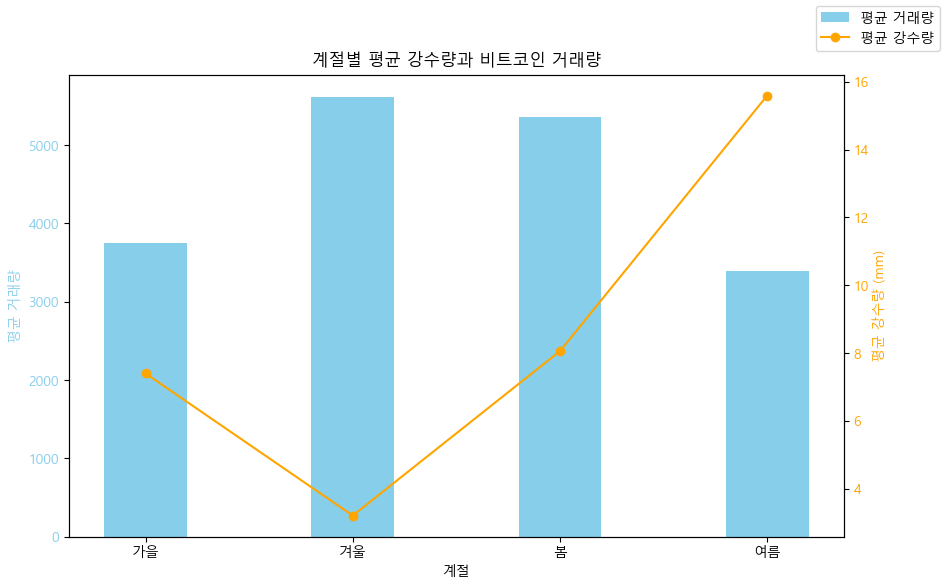

In [273]:
# 주제 2: 계절별 강수량과 비트코인 거래량 (막대그래프)
seasonal_precip_trade = df_merged.groupby('season')[['precipitation', 'candle_acc_trade_volume']].mean()
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(seasonal_precip_trade.index, seasonal_precip_trade['candle_acc_trade_volume'], 
        color='skyblue', label='평균 거래량', width=0.4)
ax1.set_xlabel('계절')
ax1.set_ylabel('평균 거래량', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

ax2 = ax1.twinx()
ax2.plot(seasonal_precip_trade.index, seasonal_precip_trade['precipitation'], 
         color='orange', marker='o', label='평균 강수량')
ax2.set_ylabel('평균 강수량 (mm)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('계절별 평균 강수량과 비트코인 거래량')
fig.legend(loc='upper right')
plt.show()

- 여름의 거래량이 다른 계절에 비해 적음. 여름에 경제적으로 좋지 못한 상황이었니

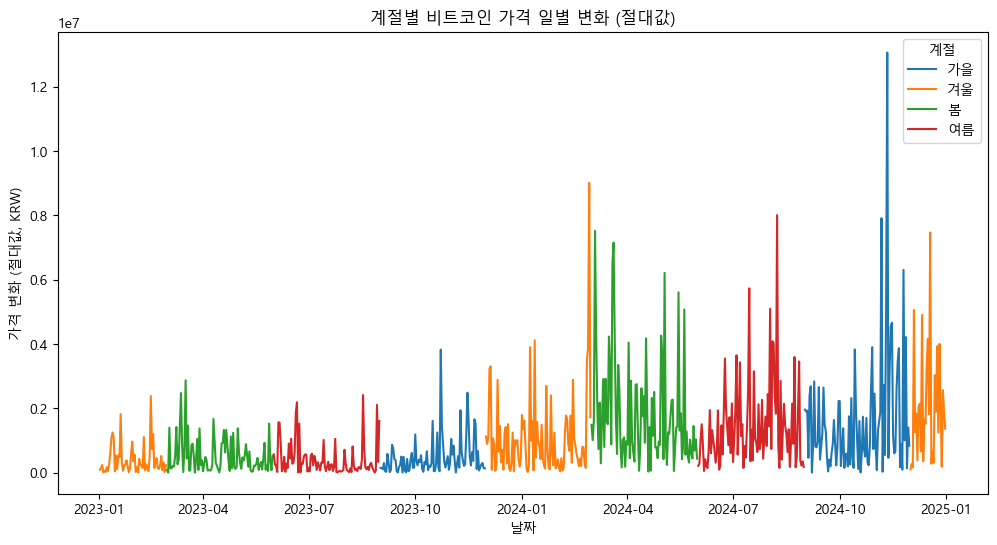

In [274]:
# 주제 3: 계절별 기온과 비트코인 가격 변화 (라인 플롯)
df_merged['price_change_abs'] = df_merged['trade_price'].diff().abs()
price_change_by_season = df_merged.groupby(['date', 'season'])['price_change_abs'].mean().unstack()

plt.figure(figsize=(12, 6))
for season in price_change_by_season.columns:
    plt.plot(price_change_by_season.index, price_change_by_season[season], label=season)
plt.title('계절별 비트코인 가격 일별 변화 (절대값)')
plt.xlabel('날짜')
plt.ylabel('가격 변화 (절대값, KRW)')
plt.legend(title='계절')
plt.show()

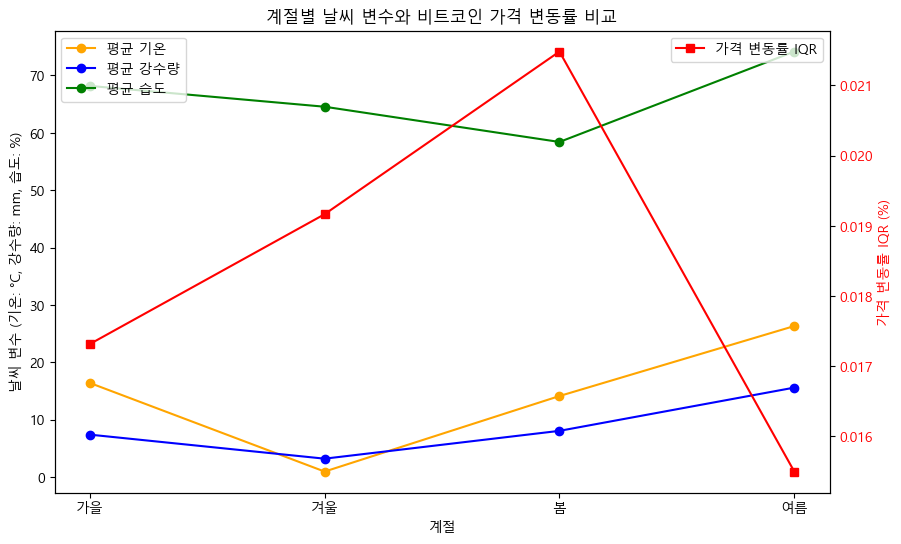

In [278]:
# 계절별 날씨 변수 평균 계산
seasonal_weather = df_merged.groupby('season')[['avg_temp', 'precipitation', 'avg_humidity']].mean()

# 계절별 가격 변동률 IQR 계산
seasonal_iqr = df_merged.groupby('season')['change_rate'].quantile(0.75) - df_merged.groupby('season')['change_rate'].quantile(0.25)

# 날씨 변수와 IQR 비교
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(seasonal_weather.index, seasonal_weather['avg_temp'], color='orange', marker='o', label='평균 기온')
ax1.plot(seasonal_weather.index, seasonal_weather['precipitation'], color='blue', marker='o', label='평균 강수량')
ax1.plot(seasonal_weather.index, seasonal_weather['avg_humidity'], color='green', marker='o', label='평균 습도')
ax1.set_xlabel('계절')
ax1.set_ylabel('날씨 변수 (기온: °C, 강수량: mm, 습도: %)')
ax1.tick_params(axis='y', labelcolor='black')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(seasonal_iqr.index, seasonal_iqr, color='red', marker='s', label='가격 변동률 IQR')
ax2.set_ylabel('가격 변동률 IQR (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('계절별 날씨 변수와 비트코인 가격 변동률 비교')
plt.show()

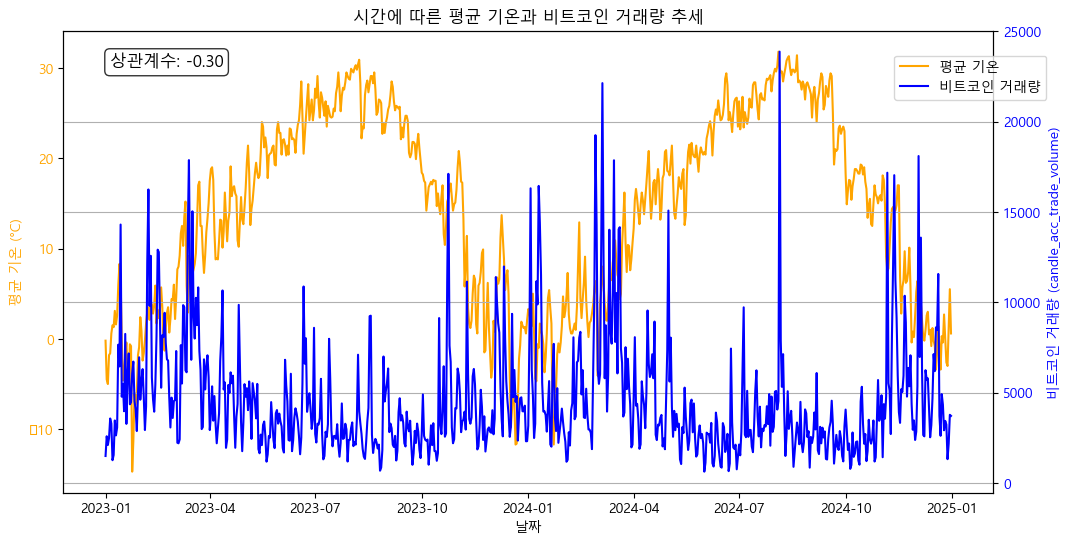

In [276]:
# 날짜별 평균 기온과 거래량 계산
daily_trend = df_merged.groupby('date')[['avg_temp', 'candle_acc_trade_volume']].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(daily_trend.index, daily_trend['avg_temp'], color='orange', label='평균 기온')
ax1.set_xlabel('날짜')
ax1.set_ylabel('평균 기온 (°C)', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')

ax2 = ax1.twinx()
ax2.plot(daily_trend.index, daily_trend['candle_acc_trade_volume'], color='blue', label='비트코인 거래량')
ax2.set_ylabel('비트코인 거래량 (candle_acc_trade_volume)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

correlation = df_merged['candle_acc_trade_volume'].corr(df_merged['avg_temp'])
plt.text(0.05, 0.95, f'상관계수: {correlation:.2f}', transform=ax1.transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('시간에 따른 평균 기온과 비트코인 거래량 추세')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.85))
plt.grid(True)
plt.show()

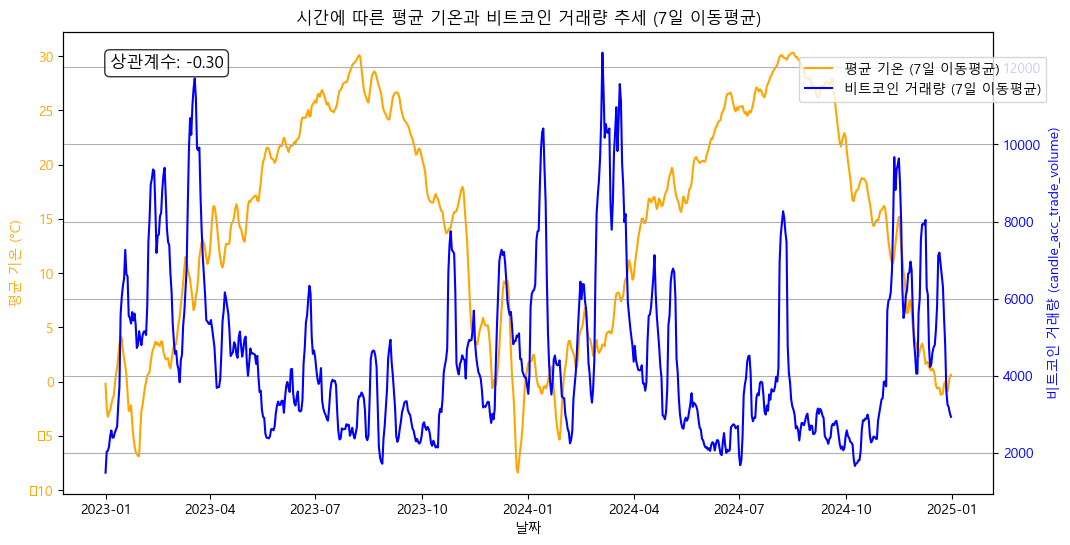

In [279]:
import matplotlib.pyplot as plt
import pandas as pd

# 날짜별 평균 기온과 거래량 계산
daily_trend = df_merged.groupby('date')[['avg_temp', 'candle_acc_trade_volume']].mean()

# 7일 이동평균으로 스무딩
daily_trend['avg_temp_smoothed'] = daily_trend['avg_temp'].rolling(window=7, min_periods=1).mean()
daily_trend['trade_volume_smoothed'] = daily_trend['candle_acc_trade_volume'].rolling(window=7, min_periods=1).mean()

# 이중 y축 라인 플롯
fig, ax1 = plt.subplots(figsize=(12, 6))

# 평균 기온 플롯 (스무딩 적용)
ax1.plot(daily_trend.index, daily_trend['avg_temp_smoothed'], color='orange', label='평균 기온 (7일 이동평균)')
ax1.set_xlabel('날짜')
ax1.set_ylabel('평균 기온 (°C)', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')

# 거래량 플롯 (스무딩 적용, 이중 y축)
ax2 = ax1.twinx()
ax2.plot(daily_trend.index, daily_trend['trade_volume_smoothed'], color='blue', label='비트코인 거래량 (7일 이동평균)')
ax2.set_ylabel('비트코인 거래량 (candle_acc_trade_volume)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# 상관계수 계산 및 주석 추가
correlation = df_merged['candle_acc_trade_volume'].corr(df_merged['avg_temp'])
plt.text(0.05, 0.95, f'상관계수: {correlation:.2f}', transform=ax1.transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 제목과 범례
plt.title('시간에 따른 평균 기온과 비트코인 거래량 추세 (7일 이동평균)')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.85))
plt.grid(True)
plt.show()

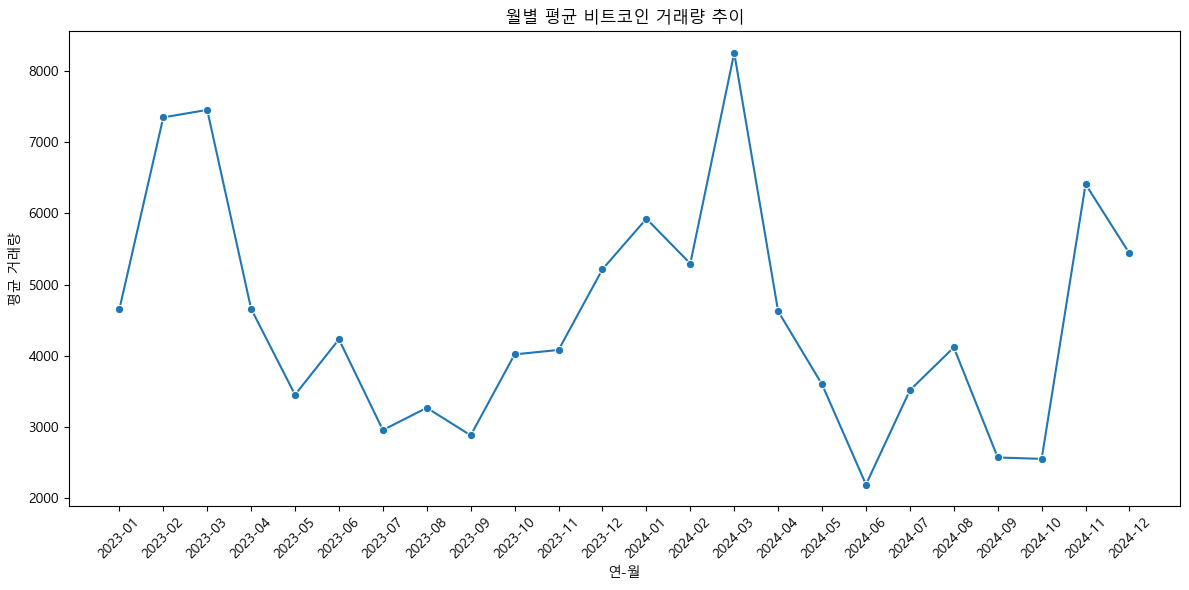

In [277]:
df_merged['year_month'] = df_merged['date'].apply(lambda x: x.strftime('%Y-%m'))

monthly_volume = df_merged.groupby('year_month')['candle_acc_trade_volume'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_volume, x='year_month', y='candle_acc_trade_volume', marker='o')
plt.title('월별 평균 비트코인 거래량 추이')
plt.xlabel('연-월')
plt.ylabel('평균 거래량')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
